#### Import

In [1]:
import sys
sys.path.insert(0, '..')

import torch
from src.gnn.seed import set_seed
from src.gnn.data import load_and_preprocess_data
from src.gnn.models import GCN
from src.gnn.training import compute_class_weights, train_with_early_stopping, evaluate, print_test_evaluation
from src.gnn.visualization import plot_learning_curves
from src.utils.multiseed import run_multiseed

#### Load data

In [2]:
data, device = load_and_preprocess_data('../data/processed/pyg_data.pt', undirected=True)

Device: cpu
Data(x=[203769, 165], edge_index=[2, 468710], y=[203769], train_mask=[203769], val_mask=[203769], test_mask=[203769])


#### Define training function for one seed

In [3]:
def run_single_gcn_seed(seed):
    set_seed(seed)
    print(f"GCN Train - Seed: {seed}")
    
    model = GCN(
        in_channels=data.x.shape[1],
        hidden_channels=64,
        out_channels=2,
        dropout=0.5,
    ).to(device)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer, 
        max_lr=0.01,
        steps_per_epoch=1, 
        epochs=300,
        pct_start=0.1,
    )
    weight = compute_class_weights(data, device)
    criterion = torch.nn.CrossEntropyLoss(weight=weight)
    
    save_path = f'../saved_models/gcn_best_seed_{seed}.pt'
    history = train_with_early_stopping(
        model, data, optimizer, criterion,
        scheduler=scheduler,
        save_path=save_path,
        num_epochs=300,
        patience=30,
        monitor_metric='f1_ill',
        clip_grad_norm=1.0
    )
    
    plot_learning_curves(history, model_name=f"GCN (Seed={seed})")
    
    model.load_state_dict(torch.load(save_path))
    model.eval()
    
    print_test_evaluation(model, data, criterion, label=f"GCN Test - Seed: {seed}")
    
    test_metrics = evaluate(model, data, criterion, data.test_mask)
    return test_metrics

#### Train with multi-seed

Start training GCN

GCN - Seed: 42
GCN Train - Seed: 42
Epoch 001: Train Loss=0.8818, Val Loss=0.9539, Train F1=0.1197, Val F1=0.0611, Gap=0.0586
Epoch 002: Train Loss=0.8573, Val Loss=0.9255, Train F1=0.1280, Val F1=0.0595, Gap=0.0684
Epoch 003: Train Loss=0.8313, Val Loss=0.8924, Train F1=0.1370, Val F1=0.0909, Gap=0.0461
Epoch 004: Train Loss=0.7934, Val Loss=0.8519, Train F1=0.1524, Val F1=0.1101, Gap=0.0424
Epoch 005: Train Loss=0.7673, Val Loss=0.8032, Train F1=0.1728, Val F1=0.1266, Gap=0.0462
Epoch 006: Train Loss=0.7373, Val Loss=0.7511, Train F1=0.2062, Val F1=0.1369, Gap=0.0694
Epoch 007: Train Loss=0.6605, Val Loss=0.7038, Train F1=0.2433, Val F1=0.1563, Gap=0.0870
Epoch 008: Train Loss=0.6041, Val Loss=0.6595, Train F1=0.3089, Val F1=0.1872, Gap=0.1217
Epoch 009: Train Loss=0.5775, Val Loss=0.6179, Train F1=0.4068, Val F1=0.3061, Gap=0.1007
Epoch 010: Train Loss=0.5014, Val Loss=0.5831, Train F1=0.4751, Val F1=0.3801, Gap=0.0950
Epoch 011: Train Loss=0.4633, Val Loss=0.554

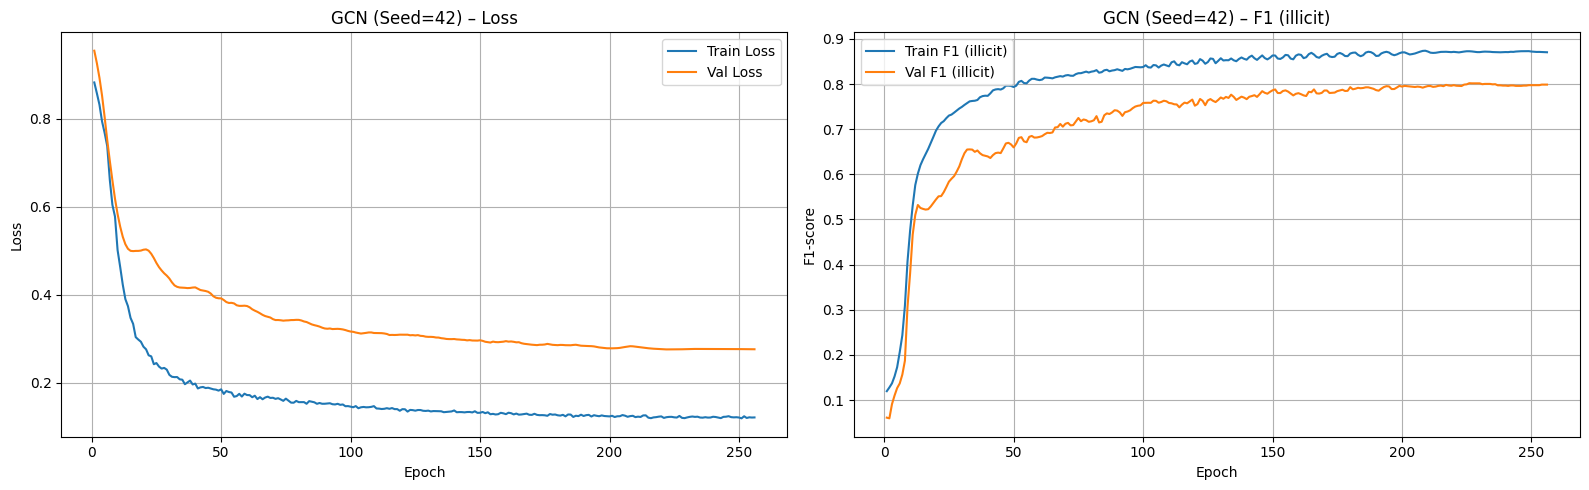

GCN Test - Seed: 42
  Loss          : 0.3293
  Accuracy      : 0.9395
  Precision(ill): 0.5318
  Recall(ill)   : 0.5799
  F1(illicit)   : 0.5548
  F1(macro)     : 0.7612
  AUC-PR        : 0.5079
Classification Report:
              precision    recall  f1-score   support

   Licit (0)     0.9706    0.9645    0.9676     15587
 Illicit (1)     0.5318    0.5799    0.5548      1083

    accuracy                         0.9395     16670
   macro avg     0.7512    0.7722    0.7612     16670
weighted avg     0.9421    0.9395    0.9407     16670

Confusion Matrix:
[[15034   553]
 [  455   628]]

GCN - Seed: 0
GCN Train - Seed: 0
Epoch 001: Train Loss=0.6347, Val Loss=0.7152, Train F1=0.0844, Val F1=0.0387, Gap=0.0457
Epoch 002: Train Loss=0.6258, Val Loss=0.7064, Train F1=0.1073, Val F1=0.0593, Gap=0.0479
Epoch 003: Train Loss=0.6239, Val Loss=0.6970, Train F1=0.1560, Val F1=0.0789, Gap=0.0771
Epoch 004: Train Loss=0.6057, Val Loss=0.6869, Train F1=0.1972, Val F1=0.1074, Gap=0.0898
Epoch 005: 

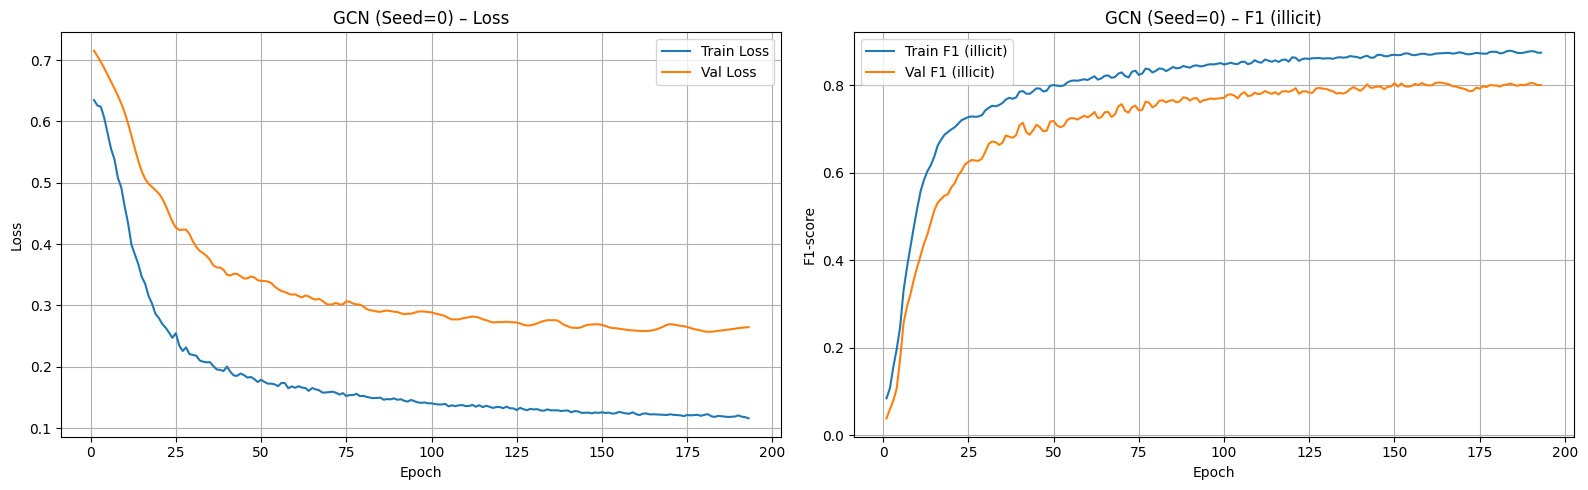

GCN Test - Seed: 0
  Loss          : 0.3357
  Accuracy      : 0.9358
  Precision(ill): 0.5054
  Recall(ill)   : 0.5651
  F1(illicit)   : 0.5336
  F1(macro)     : 0.7496
  AUC-PR        : 0.5071
Classification Report:
              precision    recall  f1-score   support

   Licit (0)     0.9695    0.9616    0.9655     15587
 Illicit (1)     0.5054    0.5651    0.5336      1083

    accuracy                         0.9358     16670
   macro avg     0.7374    0.7633    0.7496     16670
weighted avg     0.9394    0.9358    0.9375     16670

Confusion Matrix:
[[14988   599]
 [  471   612]]

GCN - Seed: 123
GCN Train - Seed: 123
Epoch 001: Train Loss=1.3421, Val Loss=1.2121, Train F1=0.1007, Val F1=0.1195, Gap=-0.0188
Epoch 002: Train Loss=1.3184, Val Loss=1.1873, Train F1=0.0994, Val F1=0.1194, Gap=-0.0200
Epoch 003: Train Loss=1.2305, Val Loss=1.1585, Train F1=0.0996, Val F1=0.1181, Gap=-0.0186
Epoch 004: Train Loss=1.2189, Val Loss=1.1226, Train F1=0.0997, Val F1=0.1221, Gap=-0.0224
Epoc

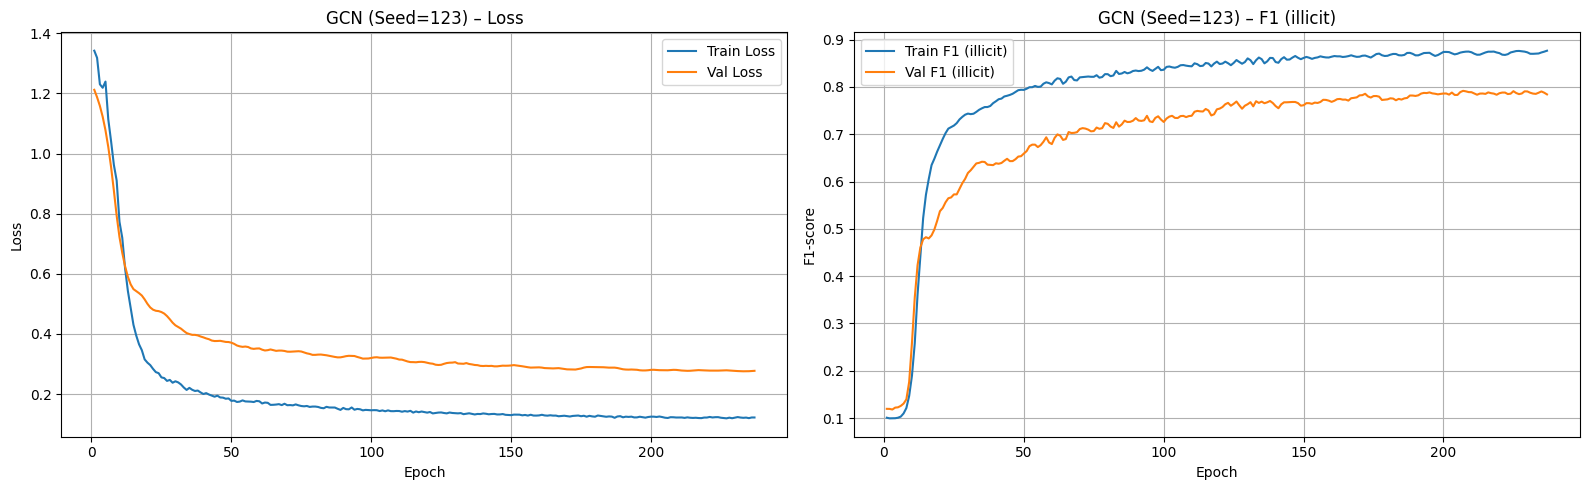

GCN Test - Seed: 123
  Loss          : 0.3510
  Accuracy      : 0.9319
  Precision(ill): 0.4799
  Recall(ill)   : 0.5734
  F1(illicit)   : 0.5225
  F1(macro)     : 0.7429
  AUC-PR        : 0.4385
Classification Report:
              precision    recall  f1-score   support

   Licit (0)     0.9700    0.9568    0.9633     15587
 Illicit (1)     0.4799    0.5734    0.5225      1083

    accuracy                         0.9319     16670
   macro avg     0.7249    0.7651    0.7429     16670
weighted avg     0.9381    0.9319    0.9347     16670

Confusion Matrix:
[[14914   673]
 [  462   621]]

 GCN multi-seed results
Loss       : 0.3387 ± 0.0091
Accuracy   : 0.9358 ± 0.0031
Precision_ill: 0.5057 ± 0.0212
Recall_ill : 0.5728 ± 0.0060
F1(illicit): 0.5369 ± 0.0134
F1_macro   : 0.7512 ± 0.0075
AUC-PR     : 0.4845 ± 0.0325


In [4]:
print("Start training GCN")
results = run_multiseed(run_single_gcn_seed, "GCN", seeds=[42, 0, 123])